# Chatbot with HITL (Human in the Loop)

Agent 처리도중 사람의 개입이 필요한 경우 iterrupt처리할 수 있다.
- 사람의 개입(tool)
- 사람 메세지(command)로 대화를 재개할 수 있다.

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://apac.api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

In [3]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=3)

### 사람 개입 도구

In [ ]:
from langchain_core.tools import tool  # Tool 데코레이터 
from langgraph.types import interrupt  # 사람 응답을 기다리는 interrupt

@tool
def human_assist(query):
    ''' 사람의 개입이 필요하면 이 도구를 사용합니다. '''
    human_response = interrupt({'query': query})  # 사람의 응답이 올때까지 입력 대기
    return human_response['data']  # 사람의 응답 데이터

In [ ]:

from typing import TypedDict, Annotated, List     # 타입 힌트 도구
from langgraph.graph.message import add_messages  # 메시지 누적 처리를 해줄 헬퍼
from langchain.chat_models import init_chat_model
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=3)

# 그래프에서 사용할 상태(TypedDict) 스키마
class State(TypedDict):
    messages: Annotated[List, add_messages]  # messages 필드가 add_messages 규칙으로 누적 저장  # 튜플형으로 저장

llm = init_chat_model('gpt-5.4-mini')
tools = [tavily_tool, human_assist]
llm_with_tools = llm.bind_tools(tools)  # llm에 도구 스펙 바인딩

# State의 messages를 입력으로 받아, 응답 메시지를 추가해주는 노드 함수
def chatbot(state: State):
    response = llm_with_tools.invoke(state['messages'])  # 누적된 메시지 리스트로 LLM 호출
    return {'messages': [response]}  # add_messages 규칙에 의해 기존 messages에 응답이 누적됨

In [7]:
# 메모리 기반 체크포인트 저장소 (인메모리)
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()  # 상태 체크포인트를 RAM에 저장하는 객체

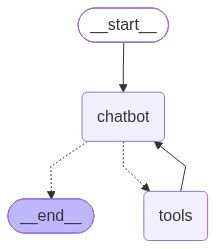

In [8]:
# langgraph.prebuilt 모듈의 ToolNode와 tools_condition 함수 사용한 빌더
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

builder = StateGraph(State)  # State 스키마 기반 그래프 설계 객체 생성
tool_node = ToolNode(tools)

builder.add_edge(START, 'chatbot')   # 시작 노드 -> chatbot 노드

builder.add_node('chatbot', chatbot)  # chatbot 노드
builder.add_node('tools', tool_node)  # tools 노드

builder.add_conditional_edges('chatbot', tools_condition)
builder.add_edge('tools', 'chatbot')

graph = builder.compile(checkpointer=memory)  # 체크포인터를 포함하여 실행 가능한 그래프로 컴파일

graph  # 그래프 객체

### 챗봇 실행

In [ ]:
from pprint import pprint

# 스냅샷 출력 함수 : 저장된 상태(message)와 다음 실행 노드(next) 확인
def print_snapshot(graph, config):
    snapshot = graph.get_state(config)  # 해당 config(thread_id)의 스냅샷 조회

    if 'messages' in snapshot.values:  # messages가 존재하면
        print(snapshot.values['messages'])  # 누적된 messages 출력
    else:
        print('메시지가 없음')

    print(f'Next: {snapshot.next}')  # 다음 실행 노드를 출력

print(print_snapshot(graph, {'configurable': {'thread_id': 'user1'}}))

메시지가 없음
Next: ()
None


In [12]:
user1_config = {'configurable': {'thread_id': 'user1'}}

state = {'messages': [('human', 'langgraph를 멀티에이전트에서 사용하는 이유가 뭐야?')]} 

response = graph.invoke(state, user1_config)  # 그래프 실행 (START -> CHATBOT -> (tool 루프) or END)
pprint(response)
print('=' * 100)
print(response['messages'][-1].content)

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


{'messages': [HumanMessage(content='멀티에이전트 설명', additional_kwargs={}, response_metadata={}, id='76498409-f6aa-4b82-86de-d386bec6f12b'),
              AIMessage(content='멀티에이전트(Multi-agent)는 **여러 개의 독립적인 에이전트가 각자 역할을 나눠 협력하거나 경쟁하면서 하나의 목표를 달성하는 구조**를 말합니다.\n\n### 간단히 말하면\n- **에이전트 1**: 정보 수집\n- **에이전트 2**: 분석\n- **에이전트 3**: 결과 정리\n- **에이전트 4**: 검증\n\n이렇게 각 에이전트가 분업해서 더 복잡한 일을 처리합니다.\n\n### 왜 쓰나?\n- **복잡한 문제를 분해**할 수 있음\n- **병렬 처리**로 속도가 빨라질 수 있음\n- 각 에이전트가 **전문 역할**을 맡아 품질을 높일 수 있음\n- 한 에이전트의 실수를 다른 에이전트가 **검토/보완** 가능\n\n### 예시\n1. **여행 계획**\n   - 한 에이전트는 항공편 검색\n   - 다른 에이전트는 호텔 검색\n   - 또 다른 에이전트는 일정 조율\n\n2. **코딩 자동화**\n   - 한 에이전트는 요구사항 이해\n   - 다른 에이전트는 코드 작성\n   - 다른 에이전트는 테스트 및 디버깅\n\n3. **고객 상담**\n   - 문의 분류 에이전트\n   - 답변 생성 에이전트\n   - 정책 검토 에이전트\n\n### 장점\n- 확장성 좋음\n- 역할 분리로 관리 쉬움\n- 협업 구조를 만들기 좋음\n\n### 단점\n- 시스템이 복잡해짐\n- 에이전트 간 조율 비용이 생김\n- 잘못 설계하면 오히려 비효율적일 수 있음\n\n원하시면 제가 다음 중 하나로 이어서 설명해드릴게요:\n1. **AI에서의 멀티에이전트 구조**\n2. **실제 구현 방식**\n3. **싱글 에이전트와 차이점**\n4. **파이썬 예시 코드**',

In [13]:
print_snapshot(graph, user1_config)

[HumanMessage(content='멀티에이전트 설명', additional_kwargs={}, response_metadata={}, id='76498409-f6aa-4b82-86de-d386bec6f12b'), AIMessage(content='멀티에이전트(Multi-agent)는 **여러 개의 독립적인 에이전트가 각자 역할을 나눠 협력하거나 경쟁하면서 하나의 목표를 달성하는 구조**를 말합니다.\n\n### 간단히 말하면\n- **에이전트 1**: 정보 수집\n- **에이전트 2**: 분석\n- **에이전트 3**: 결과 정리\n- **에이전트 4**: 검증\n\n이렇게 각 에이전트가 분업해서 더 복잡한 일을 처리합니다.\n\n### 왜 쓰나?\n- **복잡한 문제를 분해**할 수 있음\n- **병렬 처리**로 속도가 빨라질 수 있음\n- 각 에이전트가 **전문 역할**을 맡아 품질을 높일 수 있음\n- 한 에이전트의 실수를 다른 에이전트가 **검토/보완** 가능\n\n### 예시\n1. **여행 계획**\n   - 한 에이전트는 항공편 검색\n   - 다른 에이전트는 호텔 검색\n   - 또 다른 에이전트는 일정 조율\n\n2. **코딩 자동화**\n   - 한 에이전트는 요구사항 이해\n   - 다른 에이전트는 코드 작성\n   - 다른 에이전트는 테스트 및 디버깅\n\n3. **고객 상담**\n   - 문의 분류 에이전트\n   - 답변 생성 에이전트\n   - 정책 검토 에이전트\n\n### 장점\n- 확장성 좋음\n- 역할 분리로 관리 쉬움\n- 협업 구조를 만들기 좋음\n\n### 단점\n- 시스템이 복잡해짐\n- 에이전트 간 조율 비용이 생김\n- 잘못 설계하면 오히려 비효율적일 수 있음\n\n원하시면 제가 다음 중 하나로 이어서 설명해드릴게요:\n1. **AI에서의 멀티에이전트 구조**\n2. **실제 구현 방식**\n3. **싱글 에이전트와 차이점**\n4. **파이썬 예시 코드**', additional_kwargs={'refusa

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


### 케이크샵 챗봇

In [16]:
from langchain_core.prompts import ChatPromptTemplate

system_prompt = """
**Instruction**
사용자는 케이크 주문, 메뉴 문의, 매장 정보 등을 챗봇에 요청할 수 있다.
챗봇은 친절하고 정확하게 답변한다.

**Context**
당신은 프리미엄 케이크샵의 공식 챗봇이다.
- 운영 시간: 매일 09:00–21:00
- 주요 메뉴: 생크림 케이크, 초코 케이크, 치즈 케이크, 시즌 한정 케이크
- 매장 위치: 서울 강남구 신사동 123-45
- 연락처: 02-1234-5678

**Example**
> **User:** “다음 주 수요일 오후 3시에 케이크 예약 가능한가요?”
> **Bot:** “안녕하세요! 다음 주 수요일(2025년 7월 16일) 오후 3시에 예약 가능합니다. 예약을 원하시면 성함과 연락처를 알려주세요.”

**Output Indicator**
- 챗봇 응답은 한 문단 이내로 간결하게 제시한다.
- 필요한 경우 날짜·시간은 YYYY년 M월 D일 형식으로 명시한다.
- 추가 질문이 필요할 때에는 “추가로 궁금하신 점이 있으면 말씀해주세요.” 로 마무리한다.
- 그외 답변하기 어려운 경우, human_assist 도구를 사용하여 인간의 도움을 요청한다.
"""  # 시스템 지침/컨텍스트/출력 규칙 정의

user_prompt = '당근케익 4호가 홈페이지에서 구매가 안되는데, 매니져님께 구매가능여부를 묻고 싶어요.'  # 사용자 요청 문장

prompt = ChatPromptTemplate.from_messages([
    ('system', system_prompt),
    ('human', '{user_prompt}')
])

state = {'messages': prompt.format_messages(user_prompt=user_prompt)}
response = graph.invoke(state, user1_config)
print(response['messages'][-1].content)

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [ ]:
print_snapshot(graph, user1_config)  # 현재 스테이트 상태는 사용자의 답변 대기중인 상태

[HumanMessage(content='멀티에이전트 설명', additional_kwargs={}, response_metadata={}, id='76498409-f6aa-4b82-86de-d386bec6f12b'), AIMessage(content='멀티에이전트(Multi-agent)는 **여러 개의 독립적인 에이전트가 각자 역할을 나눠 협력하거나 경쟁하면서 하나의 목표를 달성하는 구조**를 말합니다.\n\n### 간단히 말하면\n- **에이전트 1**: 정보 수집\n- **에이전트 2**: 분석\n- **에이전트 3**: 결과 정리\n- **에이전트 4**: 검증\n\n이렇게 각 에이전트가 분업해서 더 복잡한 일을 처리합니다.\n\n### 왜 쓰나?\n- **복잡한 문제를 분해**할 수 있음\n- **병렬 처리**로 속도가 빨라질 수 있음\n- 각 에이전트가 **전문 역할**을 맡아 품질을 높일 수 있음\n- 한 에이전트의 실수를 다른 에이전트가 **검토/보완** 가능\n\n### 예시\n1. **여행 계획**\n   - 한 에이전트는 항공편 검색\n   - 다른 에이전트는 호텔 검색\n   - 또 다른 에이전트는 일정 조율\n\n2. **코딩 자동화**\n   - 한 에이전트는 요구사항 이해\n   - 다른 에이전트는 코드 작성\n   - 다른 에이전트는 테스트 및 디버깅\n\n3. **고객 상담**\n   - 문의 분류 에이전트\n   - 답변 생성 에이전트\n   - 정책 검토 에이전트\n\n### 장점\n- 확장성 좋음\n- 역할 분리로 관리 쉬움\n- 협업 구조를 만들기 좋음\n\n### 단점\n- 시스템이 복잡해짐\n- 에이전트 간 조율 비용이 생김\n- 잘못 설계하면 오히려 비효율적일 수 있음\n\n원하시면 제가 다음 중 하나로 이어서 설명해드릴게요:\n1. **AI에서의 멀티에이전트 구조**\n2. **실제 구현 방식**\n3. **싱글 에이전트와 차이점**\n4. **파이썬 예시 코드**', additional_kwargs={'refusa

In [ ]:
# 사람 개입
from langgraph.types import Command  # interrupt를 재개(resume)하기 위한 Command

human_response = '물론입니다. 구매 가능하시구요, 홈페이지 구매 가능하도록 채널 열어두겠습니다. 가격은 15만원입니다. 감사합니다 :>'

command = Command(resume={'data': human_response})  # interrupt에 전달할 재개 메시지
response = graph.invoke(command, user1_config)  # 중단된 그래프를 thread_id user1에서 재개 실행
print(response['messages'][-1].content)

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


안녕하세요! 당근케이크 4호는 홈페이지에서 구매 가능하며, 가격은 15만원입니다. 추가로 궁금하신 점이 있으면 말씀해주세요.


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [19]:
print_snapshot(graph, user1_config)

[HumanMessage(content='멀티에이전트 설명', additional_kwargs={}, response_metadata={}, id='76498409-f6aa-4b82-86de-d386bec6f12b'), AIMessage(content='멀티에이전트(Multi-agent)는 **여러 개의 독립적인 에이전트가 각자 역할을 나눠 협력하거나 경쟁하면서 하나의 목표를 달성하는 구조**를 말합니다.\n\n### 간단히 말하면\n- **에이전트 1**: 정보 수집\n- **에이전트 2**: 분석\n- **에이전트 3**: 결과 정리\n- **에이전트 4**: 검증\n\n이렇게 각 에이전트가 분업해서 더 복잡한 일을 처리합니다.\n\n### 왜 쓰나?\n- **복잡한 문제를 분해**할 수 있음\n- **병렬 처리**로 속도가 빨라질 수 있음\n- 각 에이전트가 **전문 역할**을 맡아 품질을 높일 수 있음\n- 한 에이전트의 실수를 다른 에이전트가 **검토/보완** 가능\n\n### 예시\n1. **여행 계획**\n   - 한 에이전트는 항공편 검색\n   - 다른 에이전트는 호텔 검색\n   - 또 다른 에이전트는 일정 조율\n\n2. **코딩 자동화**\n   - 한 에이전트는 요구사항 이해\n   - 다른 에이전트는 코드 작성\n   - 다른 에이전트는 테스트 및 디버깅\n\n3. **고객 상담**\n   - 문의 분류 에이전트\n   - 답변 생성 에이전트\n   - 정책 검토 에이전트\n\n### 장점\n- 확장성 좋음\n- 역할 분리로 관리 쉬움\n- 협업 구조를 만들기 좋음\n\n### 단점\n- 시스템이 복잡해짐\n- 에이전트 간 조율 비용이 생김\n- 잘못 설계하면 오히려 비효율적일 수 있음\n\n원하시면 제가 다음 중 하나로 이어서 설명해드릴게요:\n1. **AI에서의 멀티에이전트 구조**\n2. **실제 구현 방식**\n3. **싱글 에이전트와 차이점**\n4. **파이썬 예시 코드**', additional_kwargs={'refusa